In [1]:
# Data handling and manipulation library
import pandas as pd

# Library for numerical operations in Python
import numpy as np

# Visualizations library
import matplotlib.pyplot as plt

# Exploratory visualizations library
import seaborn as sns

# Statistical functions library
from scipy import stats

import os

from pathlib import Path

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)


In [2]:
# Load raw CSVs
t2d  = pd.read_csv("../files/T2D.csv", sep=";", encoding="latin-1")
mob  = pd.read_csv("../files/Morbidly_Obese.csv", sep=";", encoding="latin-1")
ltd  = pd.read_csv("../files/Longterm_Disease.csv", sep=";", encoding="latin-1")
fbc  = pd.read_csv("../files/Fraction_Blood_Clot.csv", sep=";", encoding="latin-1")
edu  = pd.read_csv("../files/Education_Long.csv", sep=";", encoding="latin-1")
who  = pd.read_csv("../files/WHO_Minimum_Physical_Activity.csv", sep=";", encoding="latin-1")
life = pd.read_csv("../files/Life_Expectancy.csv", sep=";", encoding="latin-1")
absn = pd.read_csv("../files/Absence.csv", sep=";", encoding="latin-1")
sab = pd.read_csv("../files/Sales-Bricks.csv", sep=";", encoding="latin-1")

# Optional datasets (not merged on brick level here)
attn = pd.read_csv("../files/Attention.csv", sep=";", encoding="latin-1")
pdat = pd.read_csv("../files/Patient_Data.csv", sep=";", encoding="latin-1")

dataframes = {
    "t2d": t2d,
    "mob": mob,
    "ltd": ltd,
    "fbc": fbc,
    "edu": edu,
    "who": who,
    "life": life,
    "absn": absn,
    "sab": sab,
}

# Quick inspect
print(t2d.shape);  print(t2d.head(3))


(60, 5)
   brick_nr          brick     patients  population patients_per_1000
0       101       Bornholm  2248,978472       33046       68,05599685
1       102         Amager  6136,772115      154254       39,78355255
2       103  Nørrebro/City  3019,148357       88293       34,19465141


In [3]:
# Quick per-file inspection
for name, df in dataframes.items():
    print("===")
    print(name)
    print("shape:", df.shape)
    print("columns:", list(df.columns[:10]) + (["..."] if len(df.columns)>10 else []))
    print("dtypes (top):")
    print(df.dtypes[:10])
    print("missing (top 8):")
    print(df.isna().sum().sort_values(ascending=False).head(8))
    print()


===
t2d
shape: (60, 5)
columns: ['brick_nr', 'brick', 'patients', 'population', 'patients_per_1000']
dtypes (top):
brick_nr              int64
brick                object
patients             object
population            int64
patients_per_1000    object
dtype: object
missing (top 8):
brick_nr             0
brick                0
patients             0
population           0
patients_per_1000    0
dtype: int64

===
mob
shape: (60, 3)
columns: ['brick_nr', 'brick', 'Andel']
dtypes (top):
brick_nr     int64
brick       object
Andel       object
dtype: object
missing (top 8):
brick_nr    0
brick       0
Andel       0
dtype: int64

===
ltd
shape: (60, 3)
columns: ['brick_nr', 'brick', 'anddel']
dtypes (top):
brick_nr     int64
brick       object
anddel      object
dtype: object
missing (top 8):
brick_nr    0
brick       0
anddel      0
dtype: int64

===
fbc
shape: (60, 3)
columns: ['brick_nr', 'brick', 'Andel med blodprop i hjertet']
dtypes (top):
brick_nr                         int64
bri

In [4]:
# Now we will clean and standardize the columns of all the datasets so we can merge them afterwards

# We'll loop through all the DataFrames again
for name, df in dataframes.items():
    # Create a cleaned version of each column name
    cleaned_columns = []
    for col in df.columns:
        new_col = (
            col.strip()            # remove leading/trailing spaces
               .lower()            # convert to lowercase
               .replace(" ", "_")  # replace spaces with underscores
               .replace("-", "_")  # replace dashes with underscores
        )
        for ch in "()[]{}$%#@!":
            new_col = new_col.replace(ch, "")
        cleaned_columns.append(new_col)

    # Apply the cleaned column names to the DataFrame
    df.columns = cleaned_columns

    # Update the DataFrame in the dictionary
    dataframes[name] = df

# Show the cleaned column names for each dataset
for name, df in dataframes.items():
    print(f"{name}: {list(df.columns)}")


t2d: ['brick_nr', 'brick', 'patients', 'population', 'patients_per_1000']
mob: ['brick_nr', 'brick', 'andel']
ltd: ['brick_nr', 'brick', 'anddel']
fbc: ['brick_nr', 'brick', 'andel_med_blodprop_i_hjertet']
edu: ['brick_nr', 'brick', 'antal', 'brick_navn', 'population', 'value_per_1000']
who: ['brick_nr', 'brick', 'andel']
life: ['brick_nr', 'brick', 'år']
absn: ['brick_nr', 'brick', 'fravær']
sab: ['year_month', 'brick_code', 'volume', 'value', 'market']


In [5]:
# Rename the brick_code to brick_nr
sab.columns = ['year_month', 'brick_nr','volume','value','market']


In [ ]:
# Make all column names lowercase and remove extra spaces
sab.columns = sab.columns.str.strip().str.lower()

# Converting volume and value to numeric
for c in ("volume", "value"):
    sab[c] = pd.to_numeric(
        sab[c].astype(str)
              .str.replace(r"[^0-9,.\-]", "", regex=True)  # fjern alt undtagen tal , . -
              .str.replace(".", "", regex=False)           # fjern tusindtals-punktum
              .str.replace(",", ".", regex=False),         # decimalkomma -> punktum
        errors="coerce"
    )

# Pivot the data so each market becomes a separate column for both volume and value
pivot = sab.pivot_table(
    index="brick_nr",
    columns="market",
    values=["volume", "value"],
    aggfunc="sum",
    fill_value=0
)

# Flatten the multi-level column names
pivot.columns = [f"{a}_{b}" for a, b in pivot.columns]
pivot = pivot.reset_index()

pivot


,brick_nr,value_DPP-IV,value_GLP-1,value_Metformin,value_New generation insulin in basal,value_SGLT-2,volume_DPP-IV,volume_GLP-1,volume_Metformin,volume_New generation insulin in basal,volume_SGLT-2
0,101,66302993,420613532,14347026,173433664,67463159,1224,4832,12808,3737,1156
1,102,296691203,861709549,45872315,436671075,300249615,6026,10647,36297,10088,5392
2,103,120326284,240293996,18310476,178808873,163177942,2687,3048,15405,4687,2637
3,104,143100792,421362321,19879315,203321253,138783331,2926,4728,16713,5198,2728
4,105,147935773,418377471,24949204,204932727,210569048,3099,5592,20406,5956,3212
...,...,...,...,...,...,...,...,...,...,...,...
57,506,171106529,371820723,21054764,281735400,152241193,2864,4892,21570,7047,3044
58,507,114868436,332958370,17920363,263346334,141557389,2187,3746,16662,7069,2520
59,508,219409426,291470422,25483960,248456148,209242563,3976,3379,20311,6338,3312
60,601,80770097,403287442,19729928,122411718,96904138,1086,5004,16603,3298,1531


In [ ]:
# Saving it as a csv file
pivot.to_csv('sales_volume_value.csv', index=False)

In [ ]:
# year_month as text
sab["year_month"] = sab["year_month"].astype(str)

# Gruppér på år + market
trend = (
    sab.groupby(["year_month", "market"], as_index=False)[["volume", "value"]]
       .sum()
       .sort_values(["market", "year_month"])
)

trend["year"] = trend["year_month"].str[:4]
yearly = trend.groupby(["year", "market"], as_index=False)[["volume", "value"]].sum()
yearly


,year,market,volume,value
0,2019,DPP-IV,92959,4573389092
1,2019,GLP-1,168979,14544308544
2,2019,Metformin,622739,641209308
3,2019,New generation insulin in basal,200145,7548844287
4,2019,SGLT-2,90093,5516902361
5,2020,DPP-IV,112168,5454753026
6,2020,GLP-1,211939,16461063273
7,2020,Metformin,762621,952597926
8,2020,New generation insulin in basal,239226,8999202071
9,2020,SGLT-2,121686,7299070450


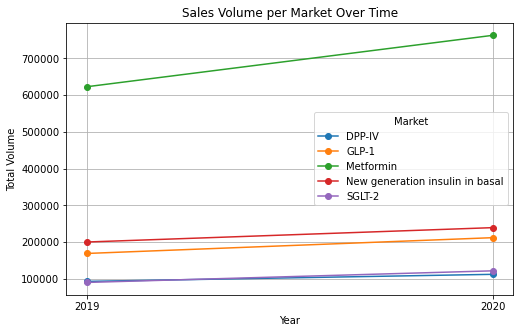

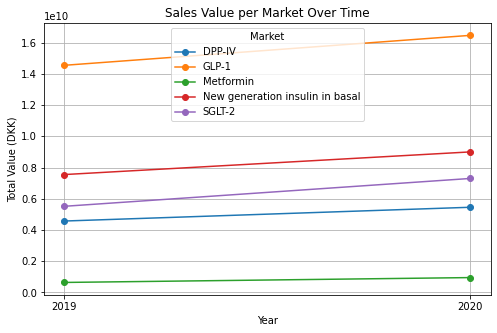

In [ ]:
# Plot: Volume over time per market
plt.figure(figsize=(8, 5))
for m in yearly["market"].unique():
    subset = yearly[yearly["market"] == m]
    plt.plot(subset["year"], subset["volume"], marker="o", label=m)

plt.title("Sales Volume per Market Over Time")
plt.xlabel("Year")
plt.ylabel("Total Volume")
plt.legend(title="Market")
plt.grid(True)
plt.show()


# Plot: Value over time per market
plt.figure(figsize=(8, 5))
for m in yearly["market"].unique():
    subset = yearly[yearly["market"] == m]
    plt.plot(subset["year"], subset["value"], marker="o", label=m)

plt.title("Sales Value per Market Over Time")
plt.xlabel("Year")
plt.ylabel("Total Value (DKK)")
plt.legend(title="Market")
plt.grid(True)
plt.show()


In [32]:
# Step 1: Strip and normalize
attn.columns = attn.columns.str.strip().str.lower()

for col in ["brick_no", "who_atc_code", "category"]:
    attn[col] = attn[col].astype(str).str.strip()  # removes invisible spaces or linebreaks
    attn.loc[attn[col].isin(["", "nan", "None"]), col] = None  # treat empty strings as NaN

# Step 2: Group again cleanly
att_grouped = (
    attn.groupby(["period_id", "brick_no", "who_atc_code", "category"], as_index=False)["count_"]
       .sum()
       .rename(columns={"count_": "clicks"})
)

# Renaming columns
att_grouped.columns = ['period_id','brick_nr','who_atc_code','market','clicks']

att_grouped


,period_id,brick_nr,who_atc_code,market,clicks
0,201907,101,A10AE04,New generation insulin in basal,7
1,201907,101,A10AE06,New generation insulin in basal,6
2,201907,101,A10BA02,Metformin,4
3,201907,101,A10BD08,DPP-IV,2
4,201907,101,A10BH05,DPP-IV,2
...,...,...,...,...,...
13336,202006,Outside DK,A10BJ06,GLP-1,125
13337,202006,Outside DK,A10BK01,SGLT-2,3636
13338,202006,Outside DK,A10BK02,SGLT-2,25
13339,202006,Outside DK,A10BK03,SGLT-2,3709


In [ ]:
# Filter only GLP-1
att_glp1 = att_grouped[att_grouped["market"].str.upper() == "GLP-1"]

# Looking at the trend over time
glp1_trend = (
    att_glp1.groupby("period_id", as_index=False)["clicks"]
            .sum()
            .sort_values("period_id")
)

glp1_trend


,period_id,clicks
0,201907,3592
1,201908,4222
2,201909,5128
3,201910,4572
4,201911,5896
5,201912,8786
6,202001,4870
7,202002,4579
8,202003,3855
9,202004,3517


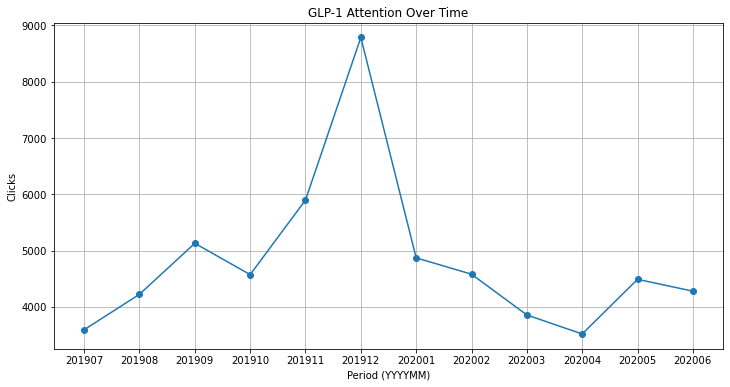

In [38]:
# Plotting the trend 

plt.figure(figsize=(12,6))
plt.plot(glp1_trend["period_id"], glp1_trend["clicks"], marker="o")
plt.title("GLP-1 Attention Over Time")
plt.xlabel("Period (YYYYMM)")
plt.ylabel("Clicks")
plt.grid(True)
plt.show()


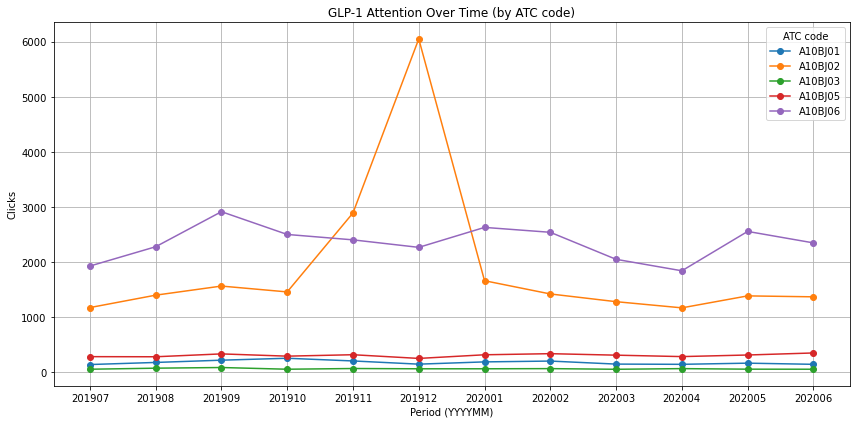

In [ ]:
# Filter only GLP-1
att_glp1 = att_grouped[att_grouped["market"].str.upper() == "GLP-1"]

# Group by month and ATC code
glp1_trend = (
    att_glp1.groupby(["period_id", "who_atc_code"], as_index=False)["clicks"]
            .sum()
            .sort_values(["who_atc_code", "period_id"])
)

# Plot one line per ATC code
plt.figure(figsize=(12,6))
for code in glp1_trend["who_atc_code"].unique():
    subset = glp1_trend[glp1_trend["who_atc_code"] == code]
    plt.plot(subset["period_id"], subset["clicks"], marker="o", label=code)

plt.title("GLP-1 Attention Over Time (by ATC code)")
plt.xlabel("Period (YYYYMM)")
plt.ylabel("Clicks")
plt.legend(title="ATC code")
plt.grid(True)
plt.tight_layout()
plt.show()


In [43]:
# Focus on GLP-1 market only
att_glp1 = att_grouped[att_grouped["market"].str.upper() == "GLP-1"]

# Group by month, brick, and ATC code
glp1_brick = (
    att_glp1.groupby(["period_id", "brick_nr", "who_atc_code"], as_index=False)["clicks"]
             .sum()
)
glp1_brick


,period_id,brick_nr,who_atc_code,clicks
0,201907,101,A10BJ02,2
1,201907,101,A10BJ06,5
2,201907,102,A10BJ01,1
3,201907,102,A10BJ02,23
4,201907,102,A10BJ03,1
...,...,...,...,...
2511,202006,Outside DK,A10BJ01,16
2512,202006,Outside DK,A10BJ02,115
2513,202006,Outside DK,A10BJ03,7
2514,202006,Outside DK,A10BJ05,30


In [ ]:
# We want to focus on two specific code: A10BJ06 and A10BJ02
focus_codes = ["A10BJ06", "A10BJ02"]

glp1_focus = (
    glp1_brick[glp1_brick["who_atc_code"].isin(focus_codes)]
    .groupby(["brick_nr", "who_atc_code"], as_index=False)["clicks"]
    .sum()
)


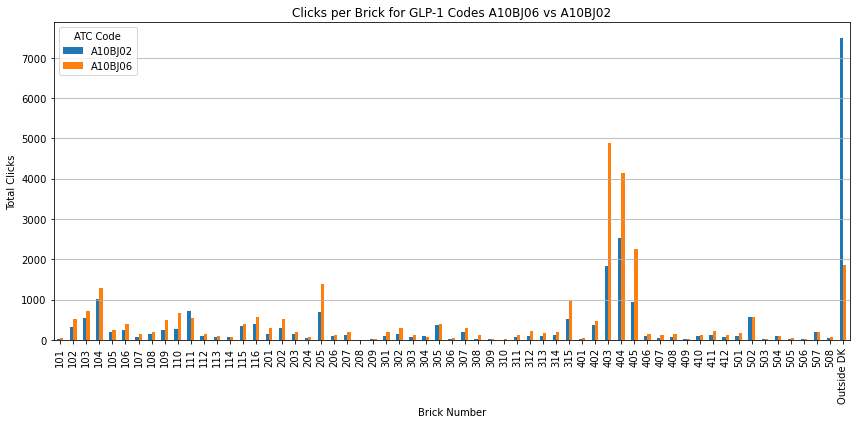

In [ ]:
# Find total clicks per brick across both codes
bricks = (
    glp1_focus.groupby("brick_nr")["clicks"].sum()
    .sort_values(ascending=False)
    .index
)

# Filter for bricks only
glp1_top = glp1_focus[glp1_focus["brick_nr"].isin(bricks)]

# Barplot comparison per brick
pivot_plot = glp1_top.pivot(index="brick_nr", columns="who_atc_code", values="clicks").fillna(0)
pivot_plot.plot(kind="bar", figsize=(12,6))

plt.title("Clicks per Brick for GLP-1 Codes A10BJ06 vs A10BJ02")
plt.xlabel("Brick Number")
plt.ylabel("Total Clicks")
plt.legend(title="ATC Code")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()


In [ ]:
# Rename for consistent keys
sales = sab.copy()
sales.columns = sales.columns.str.lower()
sales["year_month"] = sales["year_month"].astype(str)
sales["brick_nr"] = sales["brick_nr"].astype(str)

# prepare attention data
att_merged = att_grouped.copy()
att_merged["period_id"] = att_merged["period_id"].astype(str)
att_merged["brick_nr"] = att_merged["brick_nr"].astype(str)
att_merged["market"] = att_merged["market"].str.strip()


,period_id,brick_nr,who_atc_code,market,clicks
0,201907,101,A10AE04,New generation insulin in basal,7
1,201907,101,A10AE06,New generation insulin in basal,6
2,201907,101,A10BA02,Metformin,4
3,201907,101,A10BD08,DPP-IV,2
4,201907,101,A10BH05,DPP-IV,2
...,...,...,...,...,...
13336,202006,Outside DK,A10BJ06,GLP-1,125
13337,202006,Outside DK,A10BK01,SGLT-2,3636
13338,202006,Outside DK,A10BK02,SGLT-2,25
13339,202006,Outside DK,A10BK03,SGLT-2,3709


In [68]:
merged = pd.merge(
    sales,
    att_merged,
    left_on=["year_month", "brick_nr", "market"],
    right_on=["period_id", "brick_nr", "market"],
    how="inner"
)


In [69]:
focus_codes = ["A10BJ06", "A10BJ02"]
merged_glp1 = merged[
    (merged["market"].str.upper() == "GLP-1") &
    (merged["who_atc_code"].isin(focus_codes))
]

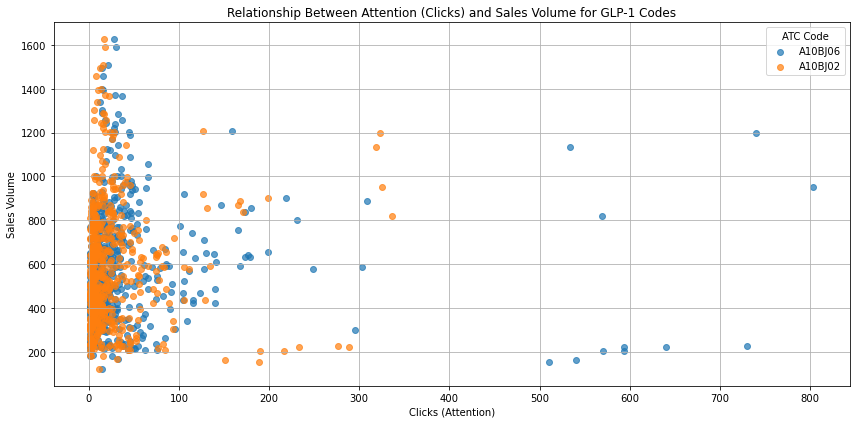

In [75]:
plt.figure(figsize=(12,6))
for code in focus_codes:
    subset = merged_glp1[merged_glp1["who_atc_code"] == code]
    plt.scatter(subset["clicks"], subset["volume"], label=code, alpha=0.7)

plt.title("Relationship Between Attention (Clicks) and Sales Volume for GLP-1 Codes")
plt.xlabel("Clicks (Attention)")
plt.ylabel("Sales Volume")
plt.legend(title="ATC Code")
plt.grid(True)
plt.tight_layout()
plt.show()


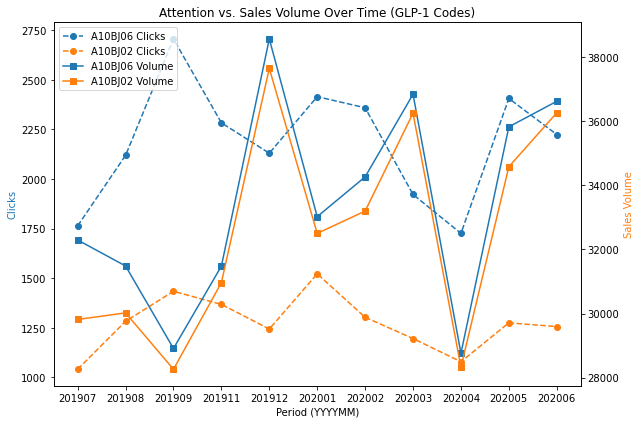

In [73]:
fig, ax1 = plt.subplots(figsize=(9,6))

for code in focus_codes:
    subset = trend[trend["who_atc_code"] == code]
    ax1.plot(subset["year_month"], subset["clicks"], marker="o", label=f"{code} Clicks", linestyle="--")

ax2 = ax1.twinx()
for code in focus_codes:
    subset = trend[trend["who_atc_code"] == code]
    ax2.plot(subset["year_month"], subset["volume"], marker="s", label=f"{code} Volume")

ax1.set_xlabel("Period (YYYYMM)")
ax1.set_ylabel("Clicks", color="tab:blue")
ax2.set_ylabel("Sales Volume", color="tab:orange")
ax1.set_title("Attention vs. Sales Volume Over Time (GLP-1 Codes)")

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.tight_layout()
plt.show()
